# Gaussian and NG covariance - MGL and Spaceborne comparison 

In [1]:
import os
import sys
import pprint
import subprocess

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing

# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')
MGL = MGLensing.MGL("ini_files/config_files/config_spaceborne.yaml")

import matplotlib.pyplot as plt
import numpy as np

SB_FOLDER = '../Spaceborne/mgl_comparison_v2'  #no_input_cl'

PyHMCode not installed!
PyHMCode not installed!
PyHMCode not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing
Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emula

In [2]:
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    # 'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.97,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'a1_IA'   : 0., 
    'eta1_IA' : 0., 
    'beta_IA' : 0.,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121, 
    'b1L_4': 0.60626, 
    'b1L_5': 0.779385,
    'b2L_1': -0.1322075,  
    'b2L_2': -0.0345375,  
    'b2L_3': 0.0579305,
    'b2L_4': 0.133662,
    'b2L_5': 0.232387,
    'bs2L_1': 0.1127485,  
    'bs2L_2': 0.0036835,  
    'bs2L_3': -0.1261985, 
    'bs2L_4': -0.285537,  
    'bs2L_5': -0.406101,  
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450, 
    'log10Mc_bc': 13.8,
    'eta_bc': -0.3,
    'beta_bc': -0.22 ,
    'log10Mz0_bc': 10.5,
    'thetaout_bc': 0.25,
    'thetainn_bc': -0.86,
    'log10Minn_bc': 12.4,
}     
# These must match the Cls exported for Spaceborne (get_c_ells).
# config_spaceborne.yaml TheoryModel uses heft_extrap_k_const=True and
# cross_sqrt_baryon=True; omitting them here defaults to False, which is
# what the *_v2.txt files (and SB) actually used.
model = {
    'nl_model' : 1,
    'bias_model' : 2,
    'baryon_model' : 3,
    'ia_model' : 0,
    'photoz_err_model' : 0,
    'heft_extrap_k_const': False,
    'cross_sqrt_baryon': False,
}

### Gaussian covariance

In [3]:
# read covariance from Spaceborne 
# covs_2d = np.load('Spaceborne/data/heft_bary_splitGauss/covmats_2D.npz')
covs_2d = np.load(SB_FOLDER + '/covmats_2D.npz')

print(covs_2d.files)
cov_sb_gauss = covs_2d['Gauss']
cov_sb_sva = covs_2d['SVA'] 
cov_sb_sn = covs_2d['SN']
cov_sb_mix = covs_2d['MIX']

['Gauss', 'SSC', 'cNG', 'SVA', 'SN', 'MIX', 'TOT', 'config', 'date_created', 'code_version', 'git_commit']


In [4]:
covs_2d['config']
MGL.Survey.d_ell_bin

array([   6.35888262,    8.38065203,   11.04523115,   14.55699757,
         19.18530951,   25.28516607,   33.32443622,   43.91974513,
         57.88377033,   76.28757538,  100.54276224,  132.5097434 ,
        174.6404386 ,  230.16634107,  303.34637835,  399.79357899,
        526.905601  ,  694.43214439,  915.22276902, 1206.21247691])

In [5]:
# read covariance from MGL
# TheoryModel is built from config_spaceborne.yaml (HEFT k-extrap = constant,
# sqrt-baryon boost on P_gm). Spaceborne's Cls were exported with get_c_ells
# using `model` below (power-law HEFT k-extrap, no sqrt-baryon boost).
# Compare like with like: build the same Theory as the exported Cls.
from MGLensing.theory import Theory
print('TheoryModel (config):  heft_extrap_k_const =', MGL.TheoryModel.flag_extrap_k_const,
      ' cross_sqrt_baryon =', MGL.TheoryModel.flag_cross_sqrt_bar_boost)
print('export / get_c_ells:   heft_extrap_k_const =', model.get('heft_extrap_k_const', False),
      ' cross_sqrt_baryon =', model.get('cross_sqrt_baryon', False))
theo_sb = Theory(MGL.Survey, model)
cov_3x2_mgl = theo_sb.compute_covariance_cosmosis_3x2pt(params)
cov_3x2_mgl_spaceborne = theo_sb.compute_covariance_spaceborne_3x2pt(params)

cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl = MGL.get_c_ells(params, model)
for i in range(MGL.Survey.nbin_s):
    cl_ll_mgl[:, i, i] -= MGL.Survey.noise['LL']
for i in range(MGL.Survey.nbin_l):
    cl_gg_mgl[:, i, i] -= MGL.Survey.noise['GG']
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc


TheoryModel (config):  heft_extrap_k_const = True  cross_sqrt_baryon = True
export / get_c_ells:   heft_extrap_k_const = False  cross_sqrt_baryon = False
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator

In [6]:
print('Shape Gauss MGL/CosmoSIS (3x2pt, full):', cov_3x2_mgl.shape)
print('Shape Gauss MGL/Spaceborne (3x2pt, full):', cov_3x2_mgl_spaceborne.shape)
print('Shape Gauss SB (3x2pt):', cov_sb_gauss.shape)

Shape Gauss MGL/CosmoSIS (3x2pt, full): (1100, 1100)
Shape Gauss MGL/Spaceborne (3x2pt, full): (1100, 1100)
Shape Gauss SB (3x2pt): (1100, 1100)


In [7]:
ndata = cov_3x2_mgl.shape[0]
pp_mgl_norm = np.zeros((ndata,ndata))
pp_mgl_sb_norm = np.zeros((ndata,ndata))
pp_sb_norm = np.zeros_like(cov_sb_gauss)
for i in range(ndata):
    for j in range(ndata):
        pp_mgl_norm[i][j] = cov_3x2_mgl[i][j]/np.sqrt(cov_3x2_mgl[i][i]*cov_3x2_mgl[j][j])  
        pp_sb_norm[i][j] = cov_sb_gauss[i][j]/np.sqrt(cov_sb_gauss[i][i]*cov_sb_gauss[j][j])   
        pp_mgl_sb_norm[i][j] = cov_3x2_mgl_spaceborne[i][j]/np.sqrt(cov_3x2_mgl_spaceborne[i][i]*cov_3x2_mgl_spaceborne[j][j])

Text(0.5, 0.98, 'Gaussian covariance - Normalised')

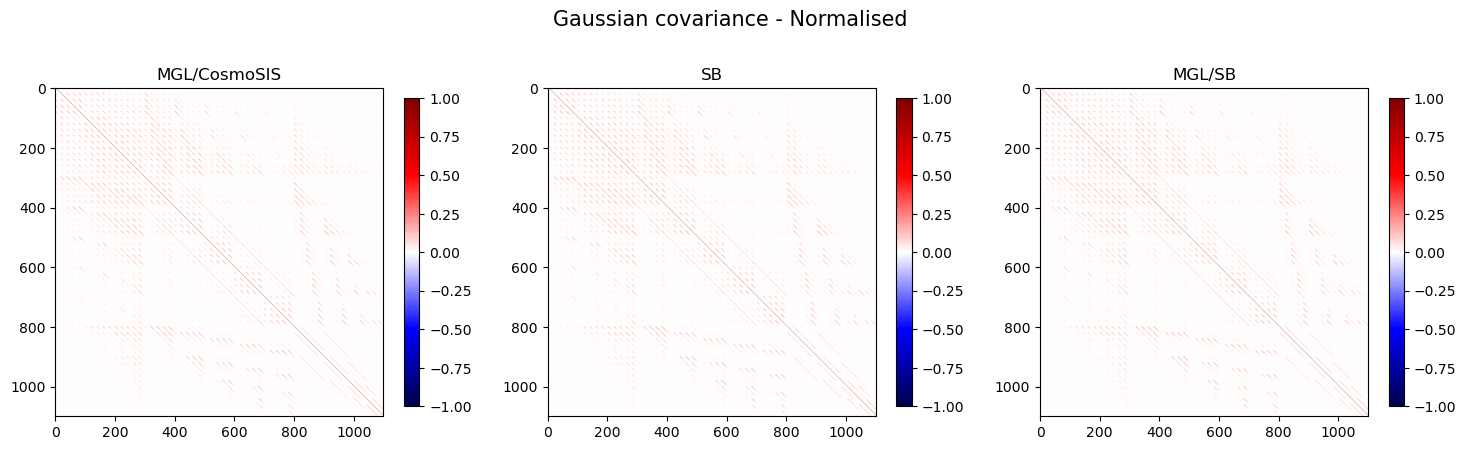

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(pp_mgl_norm, cmap='seismic', vmin=-1, vmax=1)
ax[1].imshow(pp_sb_norm, cmap='seismic', vmin=-1, vmax=1)
ax[2].imshow(pp_mgl_sb_norm, cmap='seismic', vmin=-1, vmax=1)

plt.colorbar(ax[0].images[0], ax=ax[0], shrink=0.8)
plt.colorbar(ax[1].images[0], ax=ax[1], shrink=0.8)
plt.colorbar(ax[2].images[0], ax=ax[2], shrink=0.8)
ax[0].set_title('MGL/CosmoSIS')
ax[1].set_title('SB')
ax[2].set_title('MGL/SB')
fig.suptitle('Gaussian covariance - Normalised', fontsize=15)


MGL CosmoSIS / SB
  finite elements: 60500 / 1210000
  all finite:      min=0.7799  max=0.9935
  diagonal:        min=0.793  max=0.9935  median=0.9687
  finite percentiles: p1=0.8071, p5=0.8374, p50=0.9589, p95=0.9749, p99=0.9797
  |C_SB| > 1e-6 * sqrt(C_ii C_jj): min=0.7799  max=0.9935  n=50288
  |rho_SB| > 0.01: min=0.7799  max=0.9935  n=29018

MGL Spaceborne-binning / SB
  finite elements: 60500 / 1210000
  all finite:      min=0.9998  max=1.001
  diagonal:        min=0.9998  max=1.001  median=0.9998
  finite percentiles: p1=0.9998, p5=0.9998, p50=0.9998, p95=0.9999, p99=1.001
  |C_SB| > 1e-6 * sqrt(C_ii C_jj): min=0.9998  max=1.001  n=50288
  |rho_SB| > 0.01: min=0.9998  max=1.001  n=29018


Text(0.5, 0.98, 'Gaussian covariance ratio (colour scale clipped to $0.9$–$1.1$)')

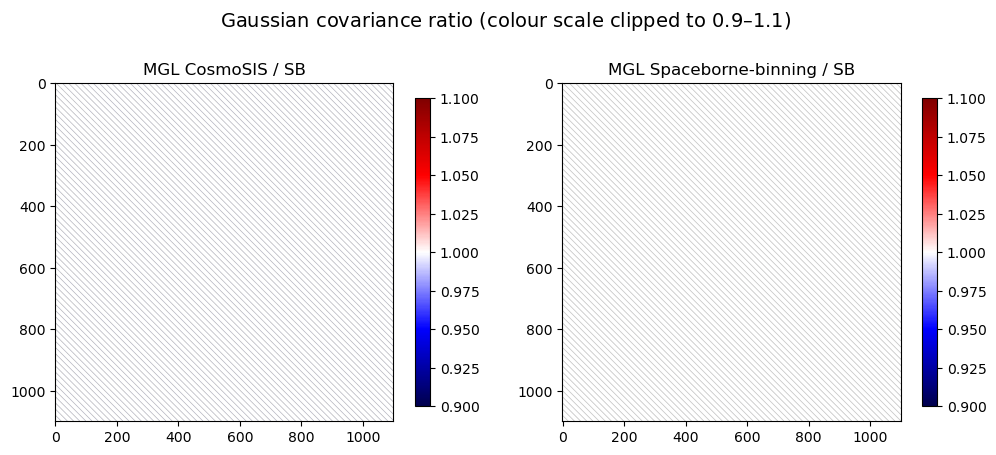

In [9]:
# Gaussian cov is ell-diagonal: most entries are 0/0 = nan. nanmin/nanmax of the
# full ratio is then dominated by tiny same-ell Wick cross-terms (SB nonzeros
# span ~1e-55 to 1e-11), not by the variances that actually matter.
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_cs = cov_3x2_mgl / cov_sb_gauss
    ratio_sb = cov_3x2_mgl_spaceborne / cov_sb_gauss

def summarise_ratio(name, ratio, cov_ref):
    finite = np.isfinite(ratio)
    diag = np.diag(ratio)
    print(f'\n{name}')
    print(f'  finite elements: {finite.sum()} / {ratio.size}')
    print(f'  all finite:      min={np.nanmin(ratio):.4g}  max={np.nanmax(ratio):.4g}')
    print(f'  diagonal:        min={diag.min():.4g}  max={diag.max():.4g}  median={np.median(diag):.4g}')
    pct = {p: np.percentile(ratio[finite], p) for p in (1, 5, 50, 95, 99)}
    print('  finite percentiles:', ', '.join(f'p{p}={v:.4g}' for p, v in pct.items()))
    # keep only entries that are a non-negligible fraction of the geometric mean of the two variances
    scale = np.sqrt(np.outer(np.diag(cov_ref), np.diag(cov_ref)))
    significant = finite & (np.abs(cov_ref) > 1e-6 * scale)
    if significant.any():
        print(f'  |C_SB| > 1e-6 * sqrt(C_ii C_jj): min={ratio[significant].min():.4g}  '
              f'max={ratio[significant].max():.4g}  n={significant.sum()}')
    # tighter cut: Gaussian correlation |C_ij|/sqrt(C_ii C_jj)
    corr = np.abs(cov_ref) / scale
    correlated = finite & (corr > 0.01)
    if correlated.any():
        print(f'  |rho_SB| > 0.01: min={ratio[correlated].min():.4g}  '
              f'max={ratio[correlated].max():.4g}  n={correlated.sum()}')
    return significant

sig_cs = summarise_ratio('MGL CosmoSIS / SB', ratio_cs, cov_sb_gauss)
sig_sb = summarise_ratio('MGL Spaceborne-binning / SB', ratio_sb, cov_sb_gauss)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(ratio_cs, cmap='seismic', vmin=0.9, vmax=1.1)
im1 = ax[1].imshow(ratio_sb, cmap='seismic', vmin=0.9, vmax=1.1)
plt.colorbar(im0, ax=ax[0], shrink=0.8)
plt.colorbar(im1, ax=ax[1], shrink=0.8)
ax[0].set_title('MGL CosmoSIS / SB')
ax[1].set_title('MGL Spaceborne-binning / SB')
fig.suptitle(r'Gaussian covariance ratio (colour scale clipped to $0.9$–$1.1$)', fontsize=14)

diagonal min/max/median: 0.9998410247093005 1.0009393343821258 0.9998410247093023
largest |ratio-1| at (19, 119): ratio=1.001,  MGL=3.573e-30, SB=3.569e-30
  decoded: ('LL', (0, 0), 19) x ('LL', (1, 1), 19)   rho_SB=9.86e-07
worst diagonal |ratio-1|:
  idx= 819  ('GG', (0, 0), 19)  ratio=1.001
  idx= 899  ('GG', (0, 4), 19)  ratio=1.001
  idx= 839  ('GG', (0, 1), 19)  ratio=1.001
  idx= 879  ('GG', (0, 3), 19)  ratio=1.001
  idx=1099  ('GG', (4, 4), 19)  ratio=1.001
  idx=1079  ('GG', (3, 4), 19)  ratio=1.001
  idx= 859  ('GG', (0, 2), 19)  ratio=1.001
  idx= 979  ('GG', (1, 4), 19)  ratio=1.001
GG last-ell-bin variance ratios: [1.00093933 1.00093542 1.00093333 1.00093452 1.00093674 1.00093004
 1.00092952 1.00092986 1.00093209 1.00092728 1.00092968 1.00093071
 1.00092967 1.00093363 1.00093413]


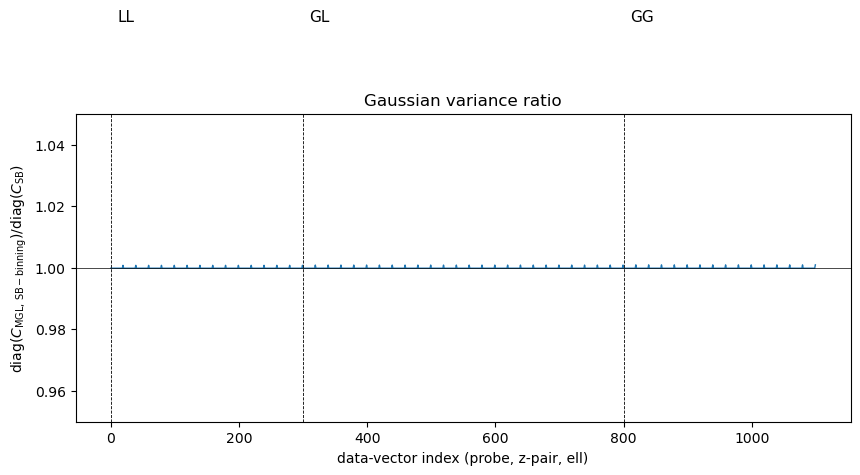

In [10]:
n_ell = MGL.Survey.lbin
n_ll = MGL.Survey.nbin_flat_s
n_gl = MGL.Survey.nbin_s * MGL.Survey.nbin_l
n_gg = MGL.Survey.nbin_flat_l
edges = np.cumsum([0, n_ell * n_ll, n_ell * n_gl, n_ell * n_gg])
labels = ['LL', 'GL', 'GG']

diag_ratio = cov_3x2_mgl_spaceborne.diagonal() / cov_sb_gauss.diagonal()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diag_ratio, lw=1)
for e, lab in zip(edges[:-1], labels):
    ax.axvline(e, color='k', lw=0.6, ls='--')
    ax.text(e + 10, 1.08, lab, fontsize=11)
ax.set_ylim(0.95, 1.05)
ax.set_xlabel('data-vector index (probe, z-pair, ell)')
ax.set_ylabel(r'$\mathrm{diag}(C_{\rm MGL,\,SB-binning}) / \mathrm{diag}(C_{\rm SB})$')
ax.set_title('Gaussian variance ratio')
ax.axhline(1.0, color='k', lw=0.5)
print('diagonal min/max/median:', diag_ratio.min(), diag_ratio.max(), np.median(diag_ratio))

def decode_idx(idx, n_ell=n_ell):
    nbin_s, nbin_l = MGL.Survey.nbin_s, MGL.Survey.nbin_l
    n_ll_el = n_ell * MGL.Survey.nbin_flat_s
    n_gl_el = n_ell * nbin_s * nbin_l
    if idx < n_ll_el:
        probe, pairs = 'LL', [(a, b) for a in range(nbin_s) for b in range(a, nbin_s)]
        pair, ell_bin = divmod(idx, n_ell)
    elif idx < n_ll_el + n_gl_el:
        probe, pairs = 'GL', [(a, b) for a in range(nbin_l) for b in range(nbin_s)]
        pair, ell_bin = divmod(idx - n_ll_el, n_ell)
    else:
        probe, pairs = 'GG', [(a, b) for a in range(nbin_l) for b in range(a, nbin_l)]
        pair, ell_bin = divmod(idx - n_ll_el - n_gl_el, n_ell)
    return probe, pairs[pair], int(ell_bin)

# Where does the full-matrix nanmax actually sit?
imax = np.nanargmax(np.abs(ratio_sb - 1.0))
i, j = np.unravel_index(imax, ratio_sb.shape)
print(f'largest |ratio-1| at ({i}, {j}): ratio={ratio_sb[i, j]:.4g},  '
      f'MGL={cov_3x2_mgl_spaceborne[i, j]:.4g}, SB={cov_sb_gauss[i, j]:.4g}')
print('  decoded:', decode_idx(i), 'x', decode_idx(j),
      f'  rho_SB={cov_sb_gauss[i, j] / np.sqrt(cov_sb_gauss[i, i] * cov_sb_gauss[j, j]):.3g}')

worst_diag = np.argsort(np.abs(diag_ratio - 1.0))[::-1][:8]
print('worst diagonal |ratio-1|:')
for k in worst_diag:
    print(f'  idx={k:4d}  {decode_idx(k)}  ratio={diag_ratio[k]:.4g}')
print('GG last-ell-bin variance ratios:',
      diag_ratio[edges[2] + n_ell - 1:edges[3]:n_ell])

diagonal min/max/median: 0.79300978888709 0.9935047899344561 0.9687301603579932
largest |ratio-1| at (19, 119): ratio=1.001,  MGL=3.378e-30, SB=3.569e-30


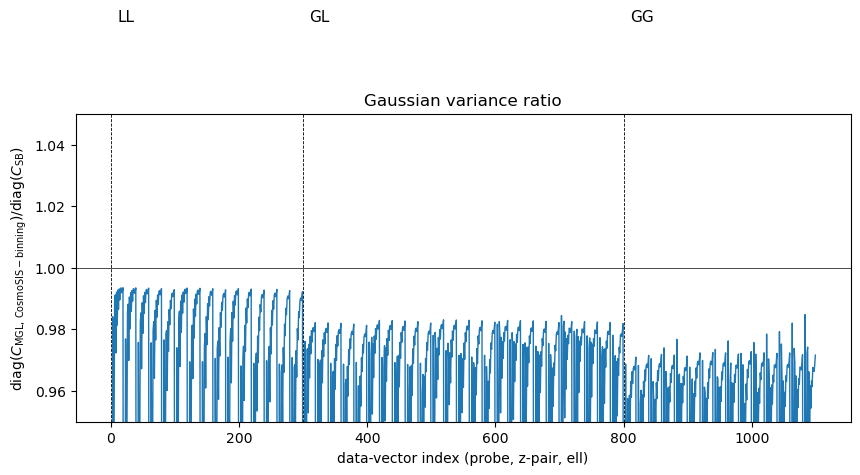

In [11]:
diag_ratio = cov_3x2_mgl.diagonal() / cov_sb_gauss.diagonal()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diag_ratio, lw=1)
for e, lab in zip(edges[:-1], labels):
    ax.axvline(e, color='k', lw=0.6, ls='--')
    ax.text(e + 10, 1.08, lab, fontsize=11)
ax.set_ylim(0.95, 1.05)
ax.set_xlabel('data-vector index (probe, z-pair, ell)')
ax.set_ylabel(r'$\mathrm{diag}(C_{\rm MGL,\,CosmoSIS-binning}) / \mathrm{diag}(C_{\rm SB})$')
ax.set_title('Gaussian variance ratio')
ax.axhline(1.0, color='k', lw=0.5)
print('diagonal min/max/median:', diag_ratio.min(), diag_ratio.max(), np.median(diag_ratio))

# Where does the full-matrix nanmax actually sit?
imax = np.nanargmax(np.abs(ratio_sb - 1.0))
i, j = np.unravel_index(imax, ratio_sb.shape)
print(f'largest |ratio-1| at ({i}, {j}): ratio={ratio_sb[i, j]:.4g},  '
      f'MGL={cov_3x2_mgl[i, j]:.4g}, SB={cov_sb_gauss[i, j]:.4g}')

# Cells
### Need to remove shot noise from MGL config file

In [12]:
def SB_read_cl_tab(filename: str, ells: np.ndarray, zbins: int, rtol: float = 0.01) -> np.ndarray:
    """Reads the Cls in the SB txt format."""
    cl_tab = np.genfromtxt(filename)
    cl_3d = np.zeros((len(ells), zbins, zbins))

    for row in cl_tab:
        ell_ix = np.argmin(np.abs(ells - row[0]))
        if abs(ells[ell_ix] / row[0] - 1) > rtol:  # compare % difference
            raise ValueError(
                f'No matching ell found for {row[0]}: closest is {ells[ell_ix]}'
            )

        zi = int(row[1])
        zj = int(row[2])
        cl = row[3]
        cl_3d[ell_ix, zi, zj] = cl

    return cl_3d

cl_ll_sb = SB_read_cl_tab(SB_FOLDER + '/cl_ll.txt', ell_l, len(MGL.Survey.zz_integr))
cl_gg_sb = SB_read_cl_tab(SB_FOLDER + '/cl_gg.txt', ell_g, len(MGL.Survey.zz_integr))
cl_gl_sb = SB_read_cl_tab(SB_FOLDER + '/cl_gl.txt', ell_x, len(MGL.Survey.zz_integr))

In [13]:
covs_6d = np.load(SB_FOLDER+'/covmats_6D.npz')
print(covs_6d.files)
cov_sb_gauss_ll = covs_6d['LLLL_Gauss']
cov_sb_gauss_gg = covs_6d['GGGG_Gauss']
cov_sb_gauss_gl = covs_6d['GLGL_Gauss']
print(cov_sb_gauss_ll.shape)
print(cov_sb_gauss_gg.shape)
print(cov_sb_gauss_gl.shape)

['LLLL_Gauss', 'LLLL_SSC', 'LLLL_cNG', 'LLLL_SVA', 'LLLL_SN', 'LLLL_MIX', 'LLLL_TOT', 'LLGL_Gauss', 'LLGL_SSC', 'LLGL_cNG', 'LLGL_SVA', 'LLGL_SN', 'LLGL_MIX', 'LLGL_TOT', 'LLGG_Gauss', 'LLGG_SSC', 'LLGG_cNG', 'LLGG_SVA', 'LLGG_SN', 'LLGG_MIX', 'LLGG_TOT', 'GLGL_Gauss', 'GLGL_SSC', 'GLGL_cNG', 'GLGL_SVA', 'GLGL_SN', 'GLGL_MIX', 'GLGL_TOT', 'GLGG_Gauss', 'GLGG_SSC', 'GLGG_cNG', 'GLGG_SVA', 'GLGG_SN', 'GLGG_MIX', 'GLGG_TOT', 'GGGG_Gauss', 'GGGG_SSC', 'GGGG_cNG', 'GGGG_SVA', 'GGGG_SN', 'GGGG_MIX', 'GGGG_TOT', 'config', 'date_created', 'code_version', 'git_commit']
(20, 20, 5, 5, 5, 5)
(20, 20, 5, 5, 5, 5)
(20, 20, 5, 5, 5, 5)


In [14]:
nbin=5
kmax07 = [478, 617, 716, 780, 818]

mgl_err_ll, mgl_err_gg, mgl_err_lg  = MGL.get_errorbars(params)


cov_flat:  (1100, 1100)
cov_flat_masked:  (1100, 1100)


i=0, j=0 ->  [1.00000543 0.99997232 1.00002162 1.00006169 0.99997059 1.00001588
 0.99999835 1.00000009 0.99999999 0.99999956 0.99999999 1.0000002
 0.99999958 1.00000013 0.99999942 1.00000007 1.00000002 0.99999987
 0.99999999 1.        ]
i=1, j=0 ->  [1.00000483 0.99998213 1.00001442 1.00004489 0.99997333 1.00001766
 0.99999745 1.00000073 0.99999999 0.99999856 0.99999999 1.00000009
 0.99999964 1.00000008 0.99999962 1.00000009 1.00000001 0.99999988
 1.         1.00000001]
i=1, j=1 ->  [1.0000042  0.99999053 1.00000779 1.00002438 0.99998405 1.00001659
 0.99999662 0.9999999  1.         0.99999649 1.00000002 1.00000008
 0.99999979 1.00000003 0.99999979 1.00000008 1.         0.99999993
 1.00000002 1.00000004]
i=2, j=0 ->  [1.00000468 0.99998438 1.00001269 1.00003989 0.99997532 1.00001765
 0.9999972  1.00000072 0.99999999 0.99999812 0.99999999 1.00000008
 0.99999967 1.00000007 0.99999966 1.00000009 1.         0.99999989
 1.         1.00000002]
i=2, j=1 ->  [1.000004   0.99999229 1.0000062  1.

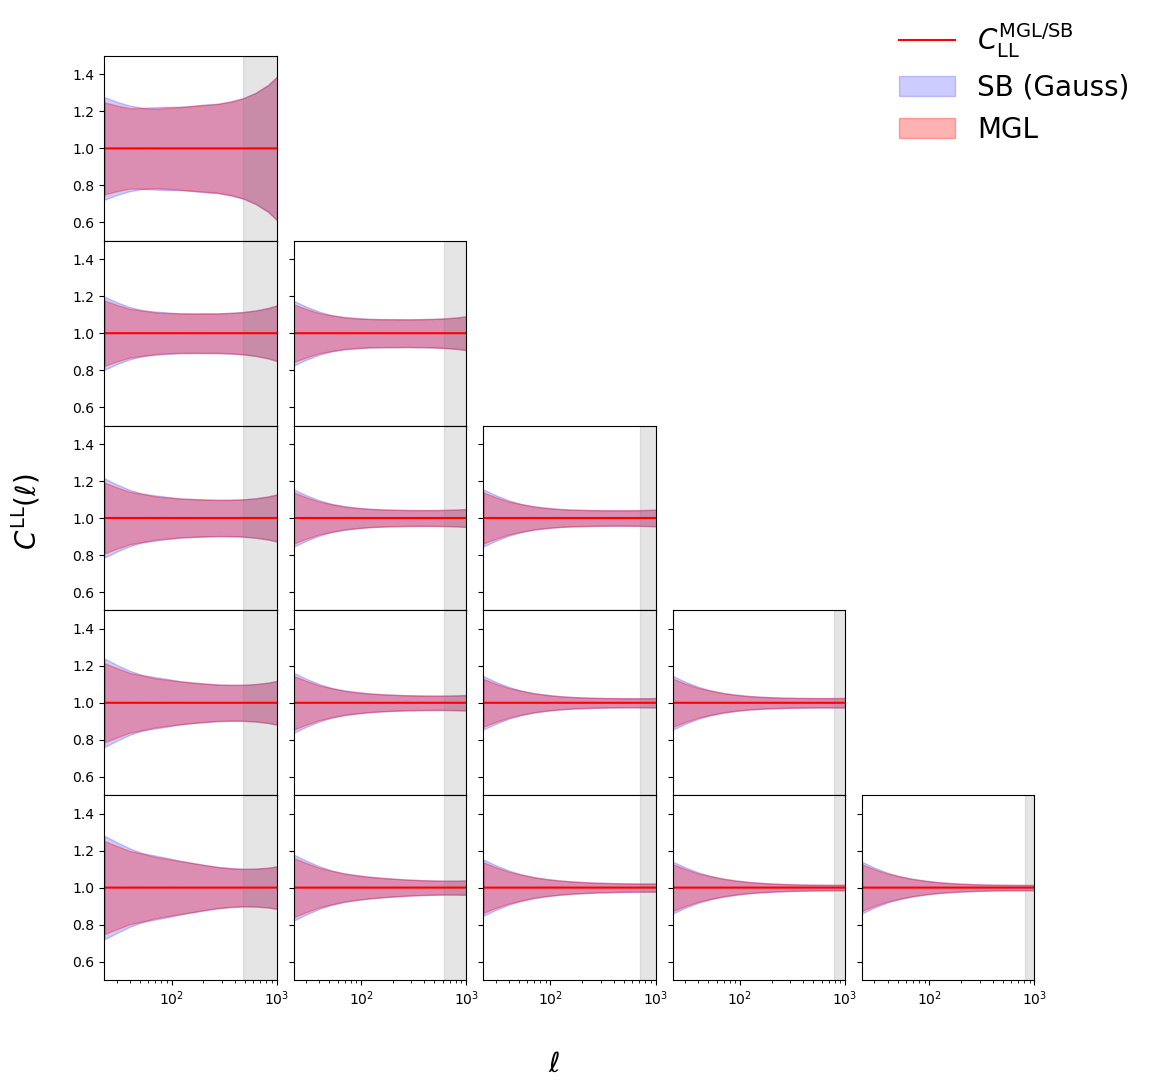

In [15]:

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:

            ratio = cl_ll_mgl[:,i,j]/cl_ll_sb[:,i,j]
            print(f'i={i}, j={j} -> ', ratio)
            ax[i,j].plot(ell_l, ratio, color='r')
            sb_err_rel = np.sqrt(np.diag(cov_sb_gauss_ll[:,:,i,j,i,j])) / np.abs(cl_ll_sb[:,i,j])
            mgl_err_rel = mgl_err_ll[:,i,j] / np.abs(cl_ll_mgl[:,i,j])
            ax[i,j].fill_between(ell_l, ratio-sb_err_rel, ratio+sb_err_rel, color='b', alpha=0.2)
            ax[i,j].fill_between(ell_l, ratio-mgl_err_rel, ratio+mgl_err_rel, color='r', alpha=0.3)

            # ax[i,j].errorbar(ell_l, cl_ll_sb[:,i,j], sb_err_ll)

            ax[i,j].set_xscale('log')
            # ax[i,j].set_yscale('log')
            ax[i,j].set_xlim(ell_l[0], 1e3)
            # ax[i,j].set_ylim(0.999999998, 1.000000005)
            ax[i,j].set_ylim(0.5, 1.5)
            ax[i,j].axvspan(5000, kmax07[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm LL}(\ell)$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([r'$C^{\rm MGL/SB}_{\rm LL}$', 'SB (Gauss)', 'MGL'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)


[1.00000516 0.99999995 0.99999999 1.00000002 1.00000001 1.00000001
 1.00000014 1.00000006 1.         1.0000005  0.99999998 1.00000028
 1.00000024 0.99999992 0.99999989 1.00000009 0.99999999 0.99999999
 0.99999998 0.99999999]


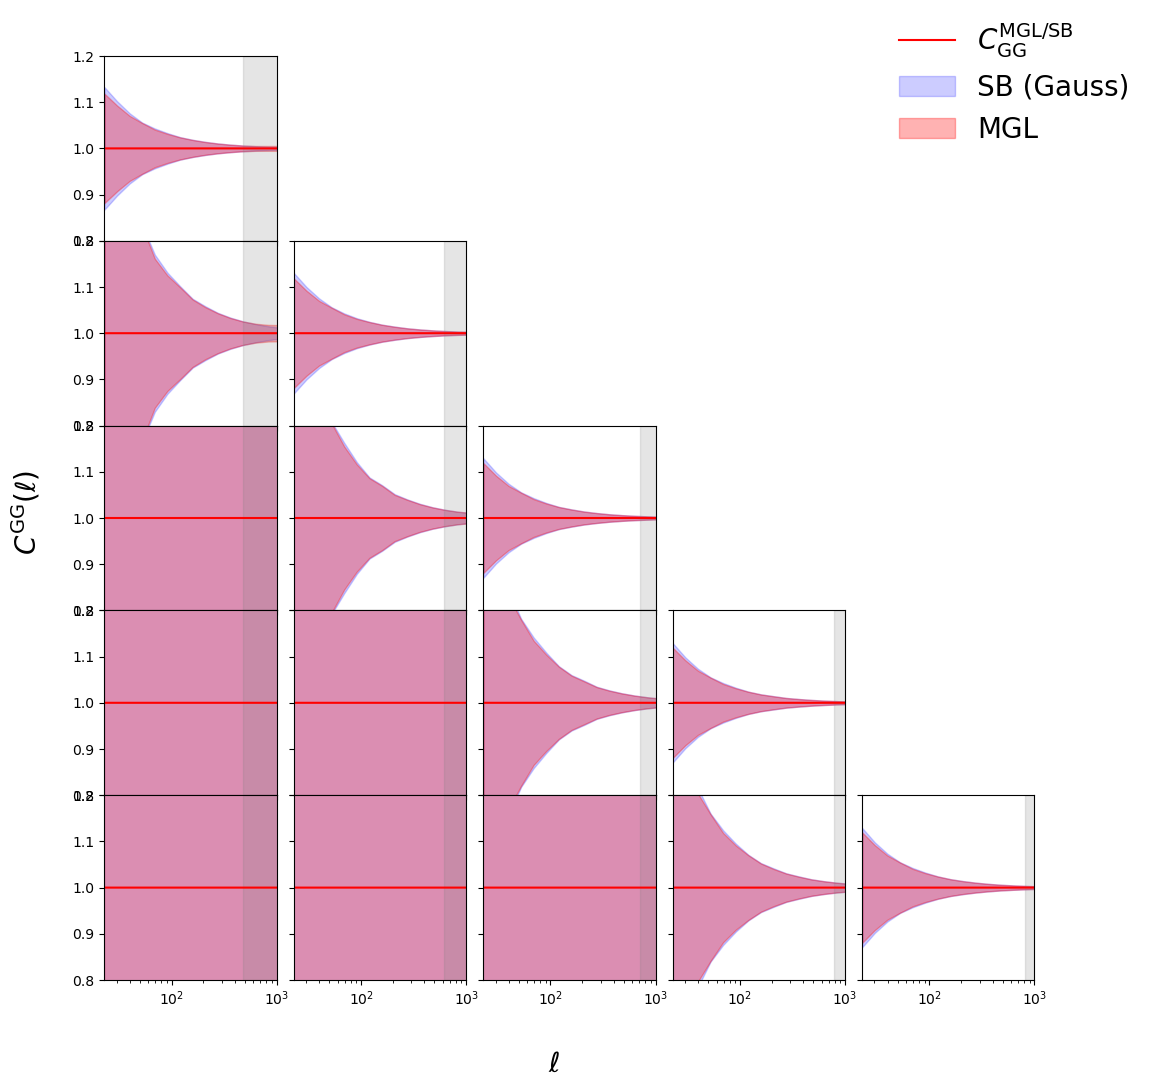

In [16]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:

            ratio = cl_gg_mgl[:,i,j]/cl_gg_sb[:,i,j]
            ax[i,j].plot(ell_l, ratio, color='r')
            sb_err_rel = np.sqrt(np.diag(cov_sb_gauss_gg[:,:,i,j,i,j])) / np.abs(cl_gg_sb[:,i,j])
            mgl_err_rel = mgl_err_gg[:,i,j] / np.abs(cl_gg_mgl[:,i,j])
            ax[i,j].fill_between(ell_l, ratio-sb_err_rel, ratio+sb_err_rel, color='b', alpha=0.2)
            ax[i,j].fill_between(ell_l, ratio-mgl_err_rel, ratio+mgl_err_rel, color='r', alpha=0.3)

            # ax[i,j].errorbar(ell_l, cl_gg_sb[:,i,j], sb_err_gg)

            ax[i,j].set_xscale('log')
            # ax[i,j].set_yscale('log')
            ax[i,j].set_xlim(ell_l[0], 1e3)
            # ax[i,j].set_ylim(7e-11, max(cl_gg[i,j]))
            ax[i, j].set_ylim(0.8, 1.2)
            ax[i,j].axvspan(5000, kmax07[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm GG}(\ell)$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([r'$C^{\rm MGL/SB}_{\rm GG}$', 'SB (Gauss)', 'MGL'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

print(ratio)

[1.0000034  0.99999993 0.99999997 1.00000002 1.00000001 0.99999996
 1.00000023 1.0000001  0.99999999 1.00000097 0.99999995 1.00000026
 1.00000046 0.99999991 0.99999989 1.0000001  0.99999999 1.00000001
 1.00000001 0.99999999]


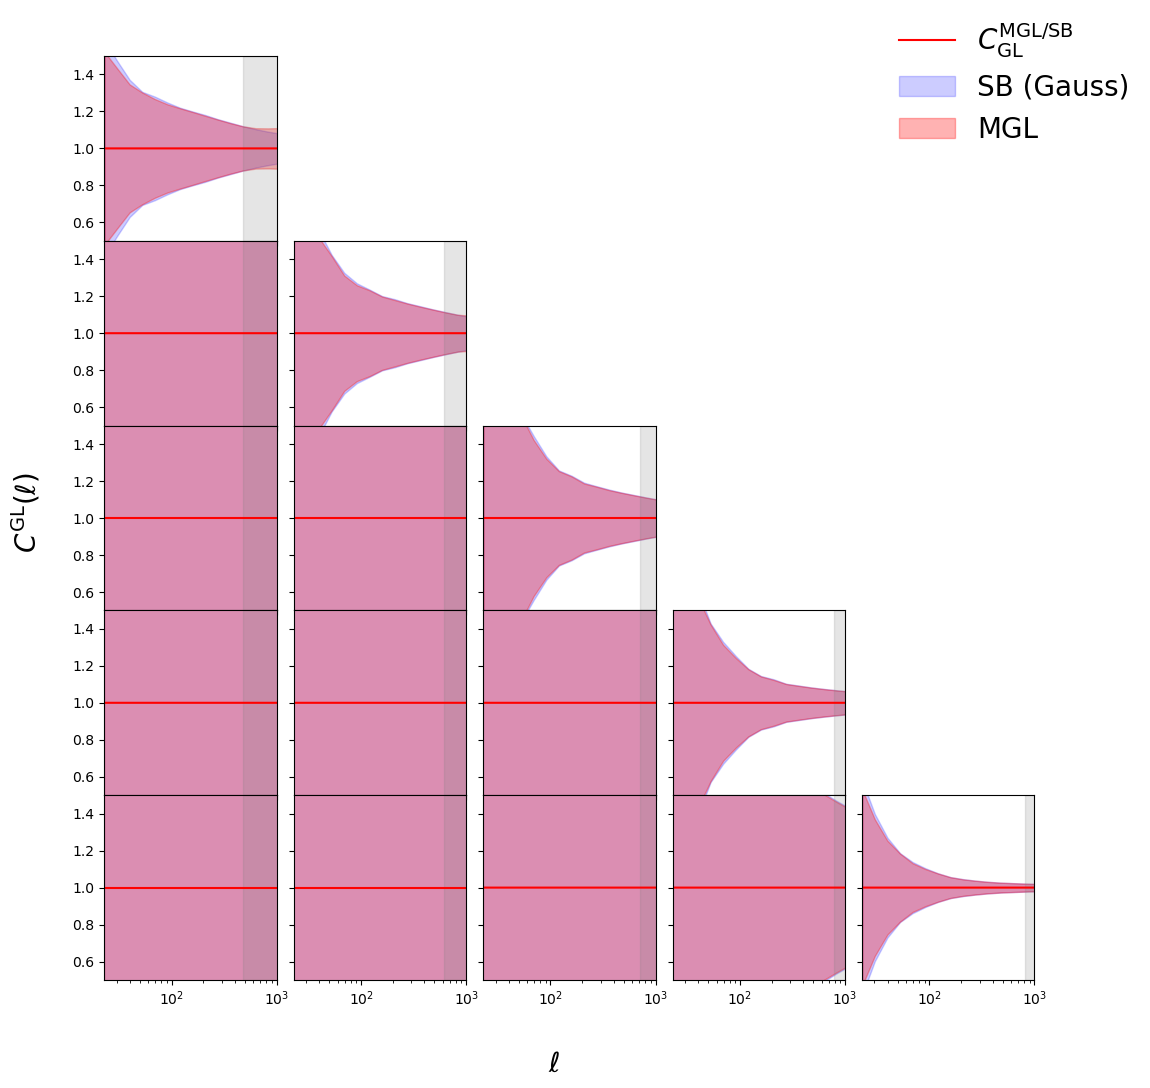

In [17]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:

            ratio = cl_gl_mgl[:,i,j]/cl_gl_sb[:,i,j]
            ax[i,j].plot(ell_l, ratio, color='r')
            sb_err_rel = np.sqrt(np.diag(cov_sb_gauss_gl[:,:,i,j,i,j])) / np.abs(cl_gl_sb[:,i,j])
            mgl_err_rel = mgl_err_lg[:,i,j] / np.abs(cl_gl_mgl[:,i,j])
            ax[i,j].fill_between(ell_l, ratio-sb_err_rel, ratio+sb_err_rel, color='b', alpha=0.2)
            ax[i,j].fill_between(ell_l, ratio-mgl_err_rel, ratio+mgl_err_rel, color='r', alpha=0.3)

            # ax[i,j].errorbar(ell_l, cl_gl_sb[:,i,j], sb_err_gl)

            ax[i,j].set_xscale('log')
            # ax[i,j].set_yscale('log')
            ax[i,j].set_xlim(ell_l[0], 1e3)
            # ax[i,j].set_ylim(7e-11, max(cl_gl[i,j]))
            ax[i, j].set_ylim(0.5, 1.5)
            ax[i,j].axvspan(5000, kmax07[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm GL}(\ell)$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([r'$C^{\rm MGL/SB}_{\rm GL}$', 'SB (Gauss)', 'MGL'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

print(ratio)